# 01 — Разведочный анализ корпуса

Смотрим, из чего состоит база знаний по личным финансам: сколько документов, как распределены по темам и какой длины тексты.

In [1]:
import sys, json
from pathlib import Path
ROOT = Path.cwd()
if ROOT.name == 'notebooks':
    ROOT = ROOT.parent
sys.path.insert(0, str(ROOT))
import pandas as pd
import matplotlib.pyplot as plt


In [2]:
corpus = json.loads((ROOT/'data/corpus.json').read_text(encoding='utf-8'))
df = pd.DataFrame(corpus)
df['n_words'] = df['text'].str.split().str.len()
df['n_chars'] = df['text'].str.len()
print('документов:', len(df))
df.head()

документов: 79


,id,topic,title,text,n_words,n_chars
0,dep-01,deposits,Что такое банковский вклад,"Банковский вклад (депозит) — это деньги, котор...",37,253
1,dep-02,deposits,Срочный вклад и вклад до востребования,Срочный вклад открывается на фиксированный пер...,37,246
2,dep-03,deposits,Капитализация процентов,"Капитализация процентов означает, что начислен...",41,295
3,dep-04,deposits,Страхование вкладов,Вклады физических лиц застрахованы государстве...,39,294
4,dep-05,deposits,Пополняемые вклады,Пополняемый вклад позволяет довносить деньги в...,26,211


## Документы по темам

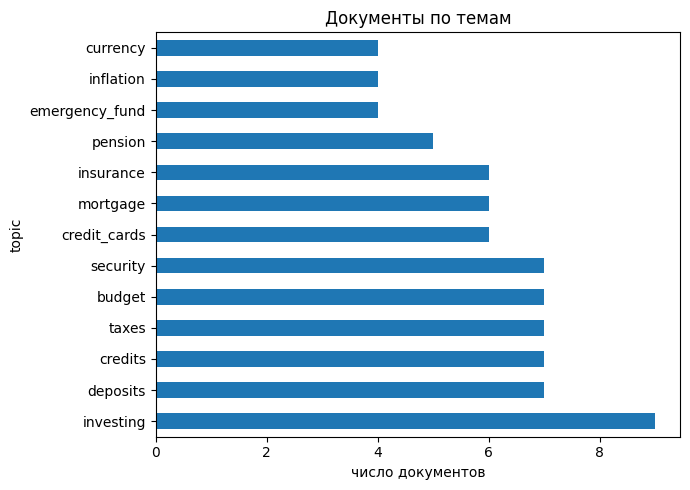

topic
investing         9
deposits          7
credits           7
taxes             7
budget            7
security          7
credit_cards      6
mortgage          6
insurance         6
pension           5
emergency_fund    4
inflation         4
currency          4
Name: count, dtype: int64

In [3]:
counts = df['topic'].value_counts()
ax = counts.plot(kind='barh', figsize=(7,5))
ax.set_xlabel('число документов'); ax.set_title('Документы по темам')
plt.tight_layout(); plt.show()
counts

## Длина документов

count    79.0
mean     31.6
std       3.8
min      24.0
25%      29.0
50%      31.0
75%      33.5
max      44.0
Name: n_words, dtype: float64


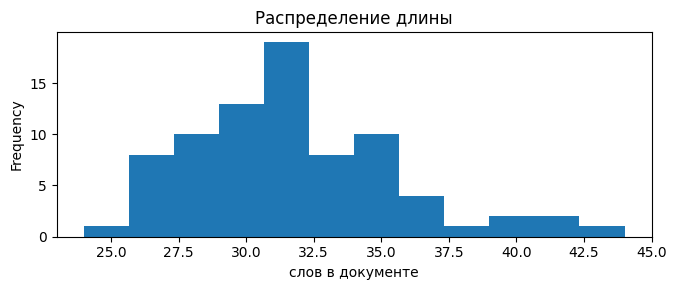

In [4]:
print(df['n_words'].describe().round(1))
ax = df['n_words'].plot(kind='hist', bins=12, figsize=(7,3))
ax.set_xlabel('слов в документе'); ax.set_title('Распределение длины')
plt.tight_layout(); plt.show()

## Чанкинг

Документы короткие (по 2–4 предложения), поэтому при текущем `chunk_size` почти каждый документ = один чанк. Проверим.

In [5]:
from src.data.loader import load_corpus
from src.data.chunking import chunk_document
from src.config import load_config
cfg = load_config()
docs = load_corpus(ROOT/'data/corpus.json')
chunks = []
for d in docs:
    chunks += chunk_document(d, cfg.chunking.chunk_size, cfg.chunking.overlap)
print('документов:', len(docs), '| чанков:', len(chunks))
print('чанков на документ:', round(len(chunks)/len(docs), 2))

документов: 79 | чанков: 79
чанков на документ: 1.0


**Вывод:** корпус сбалансирован по темам, тексты короткие и однородные. Для такого корпуса разбиение на чанки почти не играет роли — основной рычаг качества это сам способ поиска (см. ноутбук 02).